In [17]:
import torch
import numpy as np
from load_dataset import LoadDataset
from model import MLP
from torch.utils.data import DataLoader
from training import Trainer
from metrics import Evaluator
from gradients import GradMonitor
from activation_monitor import ActivationMonitor
import matplotlib.pyplot as plt  

In [2]:
iris_path = '/home/jessica/knowledge_distillation/first_experiments/dataset/iris.csv'
iris = LoadDataset(iris_path)
iris.load()
train_data, test_data = iris.split_dataset()

In [3]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [4]:
config_prof = {
    'input_dim': 4,
    'in_channels': 1,   
    'output_dim': 3,     # RGB
    'fc': [5,5],
    'criterion':  torch.nn.CrossEntropyLoss(),
    'optimizer':  torch.optim.Adam,
    'lr': 0.001
}

In [20]:
def activation_ordered(log):
    """
    Concatena (não stack!) ao longo da dimensão de amostra.
    Cada entrada de log é um batch; queremos um tensor único
    (N_total, dim) por layer, e (N_total,) para os labels.
    """
    resume = {'pred_labels': []}
    for info in log:
        resume['pred_labels'].append(info['pred_labels'])
        for layer in info['activations']:
            if layer not in resume:
                resume[layer] = []
            resume[layer].append(info['activations'][layer])
    for key in resume:
        resume[key] = torch.cat(resume[key], dim=0)
    idx = np.argsort(resume['pred_labels'].cpu().numpy())
    for key in resume:
        resume[key] = resume[key][idx]
    return resume

In [ ]:
def grad_ordered(log):
    resume = {'pred_labels': []}
    for info in log:
        pred_labels = info['pred_labels']
        resume['pred_labels'].append(pred_labels)
        for layer in info['grads']:
            if layer not in resume:
                resume[layer] = []
            resume[layer].append(info['grads'][layer])


    for key in resume:
        resume[key] = torch.cat(resume[key], dim=0)
    id_order = np.argsort(resume['pred_labels'].cpu().numpy())
    for key in resume:
        resume[key] = resume[key][id_order]
    return resume

In [54]:
log_activations_ordered['layers.fc1'].shape

torch.Size([105, 5])

In [55]:
def entropy(p):
    p = p[p > 0]  # Evitar log(0)
    return -np.sum(p * np.log(p))

def entropy_activation(log_activations, nbins=10):
    entropies = {}
    unique_labels = np.unique(log_activations['pred_labels'].cpu().numpy())
    for layer, acts in log_activations.items():
        if 'relu' in layer.lower():
            entropies[layer] = {}
            nneurons = acts.shape[1]
            for neuron in range(nneurons):
                entropies[layer][neuron] = {}
                acts_neuron = acts[:, neuron:neuron+1]
                edges = np.linspace(acts_neuron.min(), acts_neuron.max(), num=nbins)  # 10 bins
                for y in unique_labels:
                    mask = log_activations['pred_labels'] == y
                    acts_y = acts_neuron[mask]
                    counts, _ = np.histogram(acts_y.cpu().numpy(), bins=edges)
                    p = counts / counts.sum()
                    entropies[layer][neuron][y] = entropy(p)

    return entropies

entropy_activation(log_activations_ordered)

{'layers.relu1': {0: {np.int64(0): np.float64(-0.0),
   np.int64(1): np.float64(1.3074342747902294),
   np.int64(2): np.float64(1.6033260768172635)},
  1: {np.int64(0): np.float64(1.0303236737791777),
   np.int64(1): np.float64(-0.0),
   np.int64(2): np.float64(-0.0)},
  2: {np.int64(0): np.float64(1.1904500531232605),
   np.int64(1): np.float64(0.2509548043576197),
   np.int64(2): np.float64(-0.0)},
  3: {np.int64(0): np.float64(1.9561422601461025),
   np.int64(1): np.float64(1.7323378339847948),
   np.int64(2): np.float64(0.20619205063323187)},
  4: {np.int64(0): np.float64(1.3063264615392698),
   np.int64(1): np.float64(1.009230472109401),
   np.int64(2): np.float64(0.3956889307012853)}},
 'layers.relu2': {0: {np.int64(0): np.float64(-0.0),
   np.int64(1): np.float64(0.47875333041028967),
   np.int64(2): np.float64(1.5827503619740706)},
  1: {np.int64(0): np.float64(1.0518009662866796),
   np.int64(1): np.float64(0.2509548043576197),
   np.int64(2): np.float64(-0.0)},
  2: {np.int64

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
teacher = MLP(config_prof).to(device)
trainer = Trainer(teacher, config_prof)
epochs = 1000
ptrain_old = Evaluator(teacher).accuracy(train_loader)
patience = 0
entropy_history = []
for _ in range(epochs):
    trainer.train_epoch(train_loader)
    ptrain = Evaluator(teacher).accuracy(train_loader)
    if abs(ptrain_old - ptrain) < 1e-3:  # Convergence check
        patience += 1
    else:
        patience = 0
    ptrain_old = ptrain
    if patience >= 60:  # Early stopping after 5 epochs without improvement
        print(f"Early stopping at epoch {_+1}")
        break
    metrics = Evaluator(teacher)
    print(metrics.accuracy(train_loader), metrics.accuracy(test_loader))
    # teacher_monitor = GradMonitor(teacher, config_prof)
    # log_gradients = teacher_monitor.get_gradients(train_loader)
    activations = ActivationMonitor(teacher, config_prof)
    log_activations = activations.get_activations(train_loader)
    log_activations_ordered = activation_ordered(log_activations)
    log_gradients_ordered = grad_ordered(log_gradients)
    entropy_history.append(entropy_activation(log_activations_ordered))

0.3142857142857143 0.4666666666666667
0.3142857142857143 0.4666666666666667
0.3333333333333333 0.4888888888888889
0.3619047619047619 0.4888888888888889
0.37142857142857144 0.5111111111111111
0.38095238095238093 0.5333333333333333
0.3904761904761905 0.5333333333333333
0.4095238095238095 0.5777777777777777
0.4380952380952381 0.6
0.4857142857142857 0.6666666666666666
0.49523809523809526 0.6666666666666666
0.49523809523809526 0.6666666666666666
0.5523809523809524 0.6666666666666666
0.5523809523809524 0.6666666666666666
0.5619047619047619 0.6444444444444445
0.580952380952381 0.6666666666666666
0.580952380952381 0.6666666666666666
0.6190476190476191 0.6888888888888889
0.6285714285714286 0.6888888888888889
0.6285714285714286 0.6888888888888889
0.638095238095238 0.6888888888888889
0.638095238095238 0.6888888888888889
0.638095238095238 0.7111111111111111
0.638095238095238 0.7111111111111111
0.6666666666666666 0.7111111111111111
0.6666666666666666 0.7333333333333333
0.7047619047619048 0.75555555

In [59]:
entropy_history[0]

{'layers.relu1': {0: {np.int64(0): np.float64(1.3321790402101223),
   np.int64(1): np.float64(1.9405579441538545)},
  1: {np.int64(0): np.float64(1.0549201679861442),
   np.int64(1): np.float64(1.6100197036736446)},
  2: {np.int64(0): np.float64(0.6730116670092565),
   np.int64(1): np.float64(0.9025337667002135)},
  3: {np.int64(0): np.float64(0.6730116670092565),
   np.int64(1): np.float64(2.1439683869267414)},
  4: {np.int64(0): np.float64(1.3321790402101223),
   np.int64(1): np.float64(1.0247990889240663)}},
 'layers.relu2': {0: {np.int64(0): np.float64(0.9502705392332347),
   np.int64(1): np.float64(1.6235640638239692)},
  1: {np.int64(0): np.float64(1.0549201679861442),
   np.int64(1): np.float64(1.9204568631293446)},
  2: {np.int64(0): np.float64(-0.0), np.int64(1): np.float64(-0.0)},
  3: {np.int64(0): np.float64(-0.0),
   np.int64(1): np.float64(1.331104999312339)},
  4: {np.int64(0): np.float64(-0.0), np.int64(1): np.float64(-0.0)}}}

In [70]:
def get_entropy_classes(entropy_history, log_activations_ordered):
    classes = np.unique(log_activations_ordered['pred_labels'].cpu().numpy())
    entropy_classes = {}
    for i in range(len(entropy_history)):
        for layer in entropy_history[i]:
            if i==0:
                entropy_classes[layer] = {}
            for neuron in entropy_history[i][layer]:
                if i==0:
                    entropy_classes[layer][neuron] = {}
                    for y in classes:
                        entropy_classes[layer][neuron][y] = [0]
                else:
                    for y in classes:
                        entropy_classes[layer][neuron][y].append(0)
                for y in entropy_history[i][layer][neuron]:
                    entropy_classes[layer][neuron][y][i] = entropy_history[i][layer][neuron][y]
    return entropy_classes

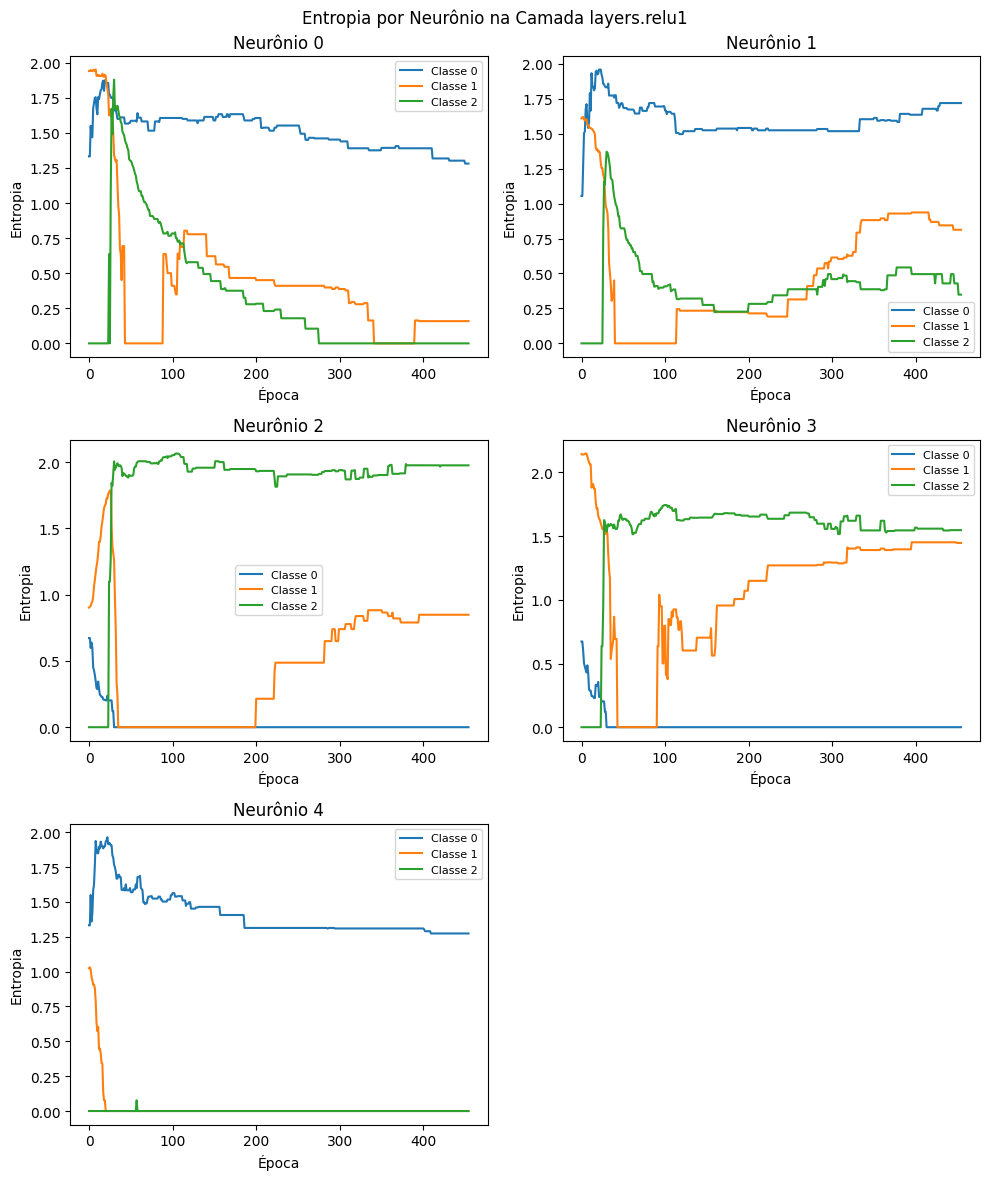

In [69]:
layers = list(entropy_classes.keys())
l1 = layers[0]
neurons = list(entropy_classes[l1].keys())

n_neurons = len(neurons)
ncols = 2  # ajuste conforme preferir
nrows = int(np.ceil(n_neurons / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, neuron in enumerate(neurons):
    ax = axes[i]
    for y in classes:
        ax.plot(entropy_classes[l1][neuron][y], label=f'Classe {y}')
    ax.set_title(f'Neurônio {neuron}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Entropia')
    ax.legend(fontsize=8)

# remove eixos vazios se n_neurons não for múltiplo de ncols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'Entropia por Neurônio na Camada {l1}')
plt.tight_layout()
plt.show()

In [7]:
# se eu for pegar a entropia da formação geométricadas classes qq tenho eu que fazer:
# intra_classe ou inter_classe e ver como a entropia isso se comporta

In [76]:
def get_student_model(T, c, teacher, train_loader, config, max_epochs=20000, patience=100, tol=1e-5):
    student = MLP(config).to(device)
    t_student = Trainer(student, config)
    ptrain = Evaluator(teacher).accuracy(train_loader)
    sold = ptrain
    patience = 0
    entropy_history_student = []
    for k in range(max_epochs):
        t_student.train_student(teacher, train_loader, T=T, c=c)
        strain = Evaluator(student).accuracy(train_loader)
        if (abs(sold - strain)) < tol:  # Convergence check
           patience += 1
        else:
           patience = 0
       
        if patience >= 50:  # Early stopping after 5 epochs without improvement
            break
        sold = strain
        activations = ActivationMonitor(t_student, config)
        log_activations = activations.get_activations(train_loader)
        log_activations_ordered = activation_ordered(log_activations)
        entropy_history_student.append(entropy_activation(log_activations_ordered))
    return student, entropy_history_student

##### Será que as informações dentro as redes sao iguais? -> vou dar uma olhada nos gradientes
---

In [72]:
config_student = {
    'input_dim': 4,
    'in_channels': 1,   
    'output_dim': 3,     # RGB
    'fc': [5],
    'criterion':  torch.nn.CrossEntropyLoss(),
    'optimizer':  torch.optim.Adam,
    'lr': 0.001
}

In [77]:
student, student_entropy_history = get_student_model(T=5, c=0.5, teacher=teacher, train_loader=train_loader, config=config_student)
student_monitor = GradMonitor(student, config_student)
log_student = student_monitor.get_gradients(train_loader) 
metrics_student = Evaluator(student)
print(metrics_student.accuracy(train_loader), metrics_student.accuracy(test_loader))

AttributeError: 'Trainer' object has no attribute 'named_modules'

In [11]:
teacher_info = {'grads' : {}, 'output':[]}
student_info = {'grads' : {}, 'output':[]}
for i in range(len(log_teacher)):
    for key in log_teacher[i]['grads']:
        if key not in teacher_info['grads']:
            teacher_info['grads'][key] = []
        
        teacher_info['grads'][key].append(log_teacher[i]['grads'][key])
        if key in log_student[i]['grads']:
            if key not in student_info['grads']:
                student_info['grads'][key] = []
            student_info['grads'][key].append(log_student[i]['grads'][key])
    teacher_info['output'].append(log_teacher[i]['pred_labels'])
    student_info['output'].append(log_student[i]['pred_labels'])

for key in teacher_info['grads']:
    teacher_info['grads'][key] = torch.cat(teacher_info['grads'][key], dim=0)
    if key in student_info['grads']:
        student_info['grads'][key] = torch.cat(student_info['grads'][key], dim=0)

teacher_info['output'] = torch.cat(teacher_info['output'], dim=0)
student_info['output'] = torch.cat(student_info['output'], dim=0)

In [12]:
idteacher = np.argsort(teacher_info['output'].cpu().numpy())
idstudent = np.argsort(student_info['output'].cpu().numpy())

for key in teacher_info['grads']:
    teacher_info['grads'][key] = teacher_info['grads'][key][idteacher]
    if key in student_info['grads']:
        student_info['grads'][key] = student_info['grads'][key][idstudent]

teacher_info['output'] = teacher_info['output'][idteacher]
student_info['output'] = student_info['output'][idstudent]

In [13]:
from pruning_utils import compute_similarity_matrix

In [14]:
teacher_sim_matrix = {}
student_sim_matrix = {}
for key in teacher_info['grads']:
    if 'bias' in key:
        continue
    teacher_sim_matrix[key] = compute_similarity_matrix(teacher_info['grads'][key])
    if key in student_info['grads']:
        student_sim_matrix[key] = compute_similarity_matrix(student_info['grads'][key])
        

/tmp/ipykernel_992664/1159523145.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


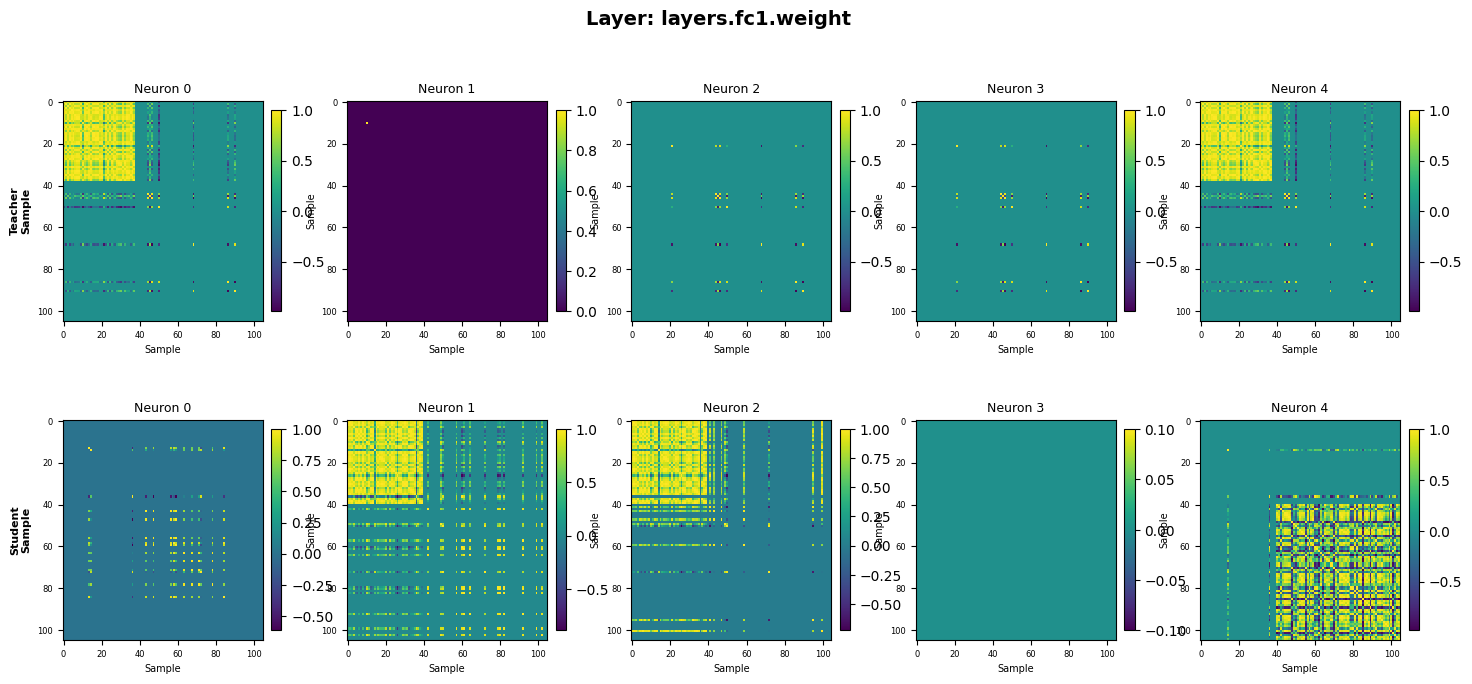

Saved: prof55student5_v2_layers.fc1.weight.png


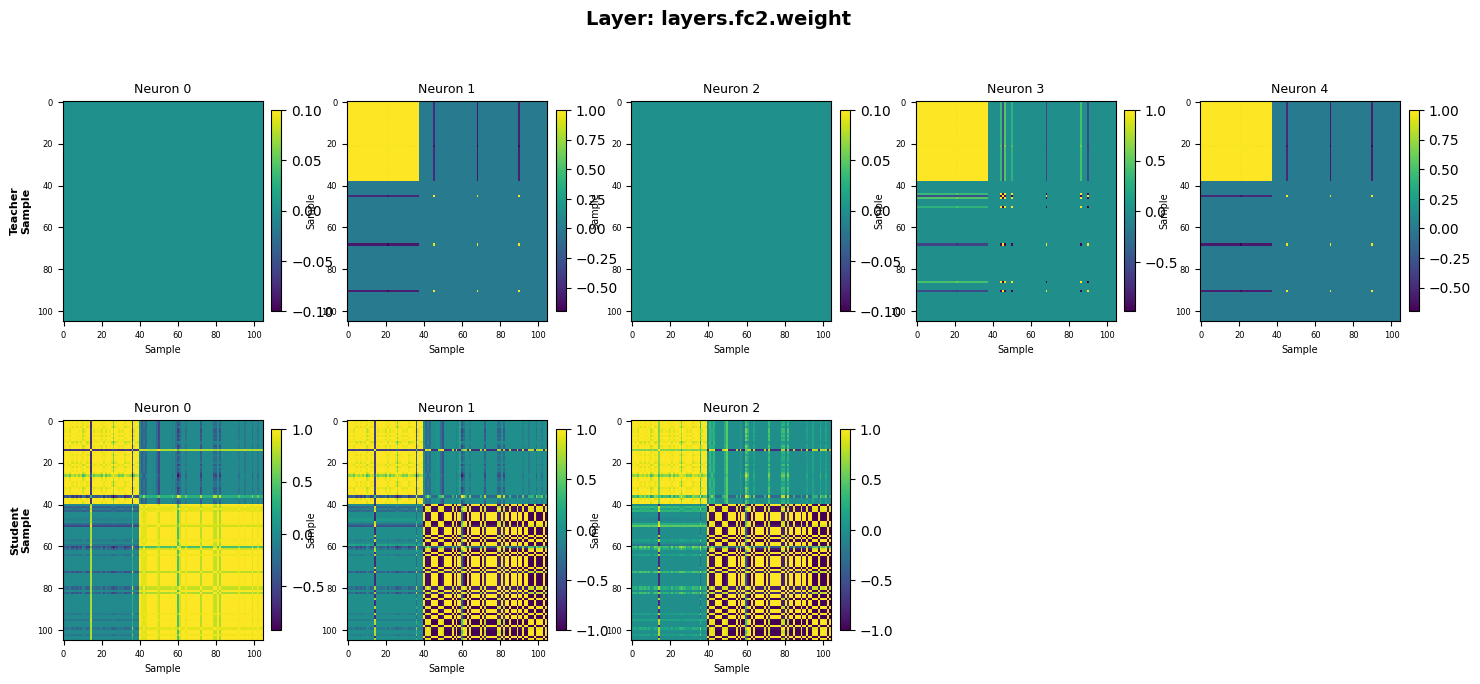

Saved: prof55student5_v2_layers.fc2.weight.png


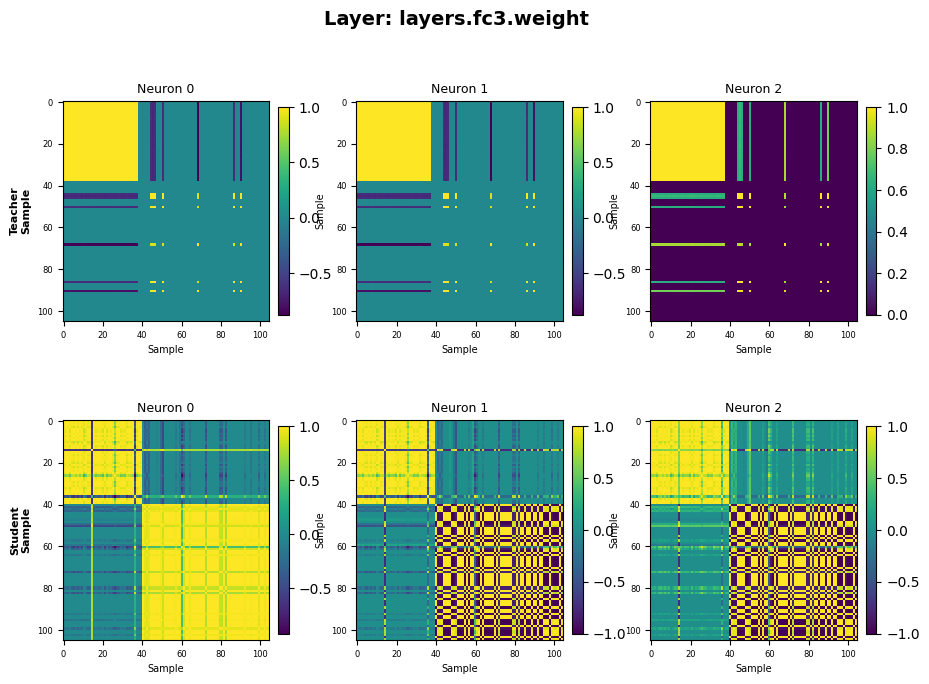

Saved: prof55student5_v2_layers.fc3.weight.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_sim_matrices(teacher_sim_matrix, student_sim_matrix, fname):
    """
    Plots similarity matrices for each neuron of each layer,
    comparing teacher (left) vs student (right).

    Args:
        teacher_sim_matrix: dict {layer_key: tensor of shape (N_teacher, nsamples, nsamples)}
        student_sim_matrix: dict {layer_key: tensor of shape (N_student, nsamples, nsamples)}
    """
    for layer_key in teacher_sim_matrix:
        t_mats = teacher_sim_matrix[layer_key]  # (N_t, S, S)
        if layer_key in student_sim_matrix:
            s_mats = student_sim_matrix[layer_key]  # (N_s, S, S)

        # Convert to numpy if tensors
        if hasattr(t_mats, 'cpu'):
            t_mats = t_mats.cpu().numpy()
            if layer_key in student_sim_matrix:
                s_mats = s_mats.cpu().numpy()

        n_teacher = t_mats.shape[0]
        n_student = s_mats.shape[0]
        n_cols    = max(n_teacher, n_student)

        fig = plt.figure(figsize=(3.5 * n_cols, 7))
        fig.suptitle(f"Layer: {layer_key}", fontsize=14, fontweight='bold', y=1.01)

        # Two rows: teacher on top, student on bottom
        outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.45)

        for row_idx, (label, mats, n_neurons) in enumerate([
            ("Teacher", t_mats, n_teacher),
            ("Student", s_mats, n_student),
        ]):
            inner = gridspec.GridSpecFromSubplotSpec(
                1, n_cols, subplot_spec=outer[row_idx], wspace=0.3
            )

            for neuron_idx in range(n_cols):
                ax = fig.add_subplot(inner[neuron_idx])

                if neuron_idx < n_neurons:
                    mat = mats[neuron_idx]
                    vmin, vmax = mat.min(), mat.max()
                    im = ax.imshow(mat, aspect='auto', cmap='viridis',
                                   vmin=vmin, vmax=vmax, interpolation='nearest')
                    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                    ax.set_title(f"Neuron {neuron_idx}", fontsize=9)
                    ax.set_xlabel("Sample", fontsize=7)
                    ax.set_ylabel("Sample", fontsize=7)
                    ax.tick_params(labelsize=6)
                else:
                    # Pad empty slots so grids align between teacher/student
                    ax.axis('off')
                    ax.set_facecolor('#f0f0f0')

                # Row label only on the first column
                if neuron_idx == 0:
                    ax.set_ylabel(f"{label}\nSample", fontsize=8, fontweight='bold')

        plt.tight_layout()
        plt.savefig(f"{fname}_{layer_key}.png", dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fname}_{layer_key}.png")


# ── run ───────────────────────────────────────────────────────────────────────
plot_sim_matrices(teacher_sim_matrix, student_sim_matrix, "prof55student5_v2")